# video 처럼 다루어 보자

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
import tifffile as tiff
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision import transforms
from sklearn.model_selection import train_test_split
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import torch.optim as optim

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### train, eval 함수 정의 (Naive ver과 동일)

In [23]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50, patience=10):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None
    no_improve_count = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        # Training loop
        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total
        train_losses.append(train_loss)

        # Validation loop
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

        # Check for improvement
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            no_improve_count = 0
        else:
            no_improve_count += 1

        # Early stopping
        if no_improve_count >= patience:
            print("Early stopping triggered. Training stopped.")
            break

    # Load the best model state
    if best_model_state:
        model.load_state_dict(best_model_state)

    return train_losses, val_losses


def evaluate_model_with_cm(model, val_loader, num_classes=8):
    model.eval()
    all_labels = []
    all_predictions = []
    
    with torch.no_grad():
        # tqdm으로 진행 상황 표시
        for images, labels in tqdm(val_loader, desc="Evaluation Progress"):
            images, labels = images.to(device), labels.to(device)  # device로 데이터 이동

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())  # 실제 라벨
            all_predictions.extend(predicted.cpu().numpy())  # 예측된 라벨

    # 라벨 범위 설정
    labels = np.arange(0, num_classes)

    # Confusion matrix 계산
    cm = confusion_matrix(all_labels, all_predictions, labels=labels)

    # Confusion matrix 시각화
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

    # Classification report 계산
    report = classification_report(all_labels, all_predictions, labels=labels, target_names=[str(label) for label in labels])
    
    print("Classification Report:")
    print(report)


### Dataset 클래스 정의 (Naive ver과 동일)

In [24]:
class TiffDataset(Dataset):
    def __init__(self, large_tif_dir, file_list, label_file, patch_size=3, box_filter_fn=None, transform=None):
        """
        Args:
            large_tif_dir (str): 여러 개의 큰 TIFF 파일이 저장된 디렉토리 경로.
            file_list (list of str): 처리할 원천 데이터 파일명 리스트.
            label_file (str): 라벨 정보를 담은 CSV 파일 경로 ("file", "x_pos", "y_pos", "label" 열 포함).
            patch_size (int): 슬라이싱할 이미지의 크기 (기본값: 3).
            box_filter_fn (callable, optional): 박스 번호 필터링 함수. 
                - 입력: 박스 번호 (1부터 100까지)
                - 출력: 해당 박스를 사용할지 여부 (True/False).
                - 기본값: None (모든 박스 사용).
            transform (callable, optional): 이미지 전처리에 사용할 함수.
        """
        self.large_tif_dir = large_tif_dir
        self.file_list = set(file_list)
        self.label_df = pd.read_csv(label_file)

        # 박스 필터 함수 설정 (기본값: 모든 박스 사용)
        self.box_filter_fn = box_filter_fn or (lambda box_number: True)

        # 파일명 필터링: file_list에 있는 파일만 유지
        self.label_df = self.label_df[self.label_df['file'].isin(self.file_list)].reset_index(drop=True)

        # 박스 번호 필터링
        self.label_df = self.label_df[self.label_df['box_number'].apply(self.box_filter_fn)].reset_index(drop=True)

        self.patch_size = patch_size
        self.transform = transform

        # 각 파일명을 키로 하고 이미지를 값으로 가지는 딕셔너리
        self.image_cache = {}

    def _load_image(self, file_name):
        """파일 이름에 해당하는 이미지를 로드하여 캐시에 저장."""
        if file_name not in self.image_cache:
            file_path = os.path.join(self.large_tif_dir, file_name)
            if not os.path.exists(file_path):
                raise FileNotFoundError(f"Image file '{file_path}' not found.")
            self.image_cache[file_name] = tiff.imread(file_path)
        return self.image_cache[file_name]

    def __len__(self):
        return len(self.label_df)

    def __getitem__(self, idx):
        # 현재 인덱스에 해당하는 데이터 가져오기
        row = self.label_df.iloc[idx]
        file_name = row["file"]
        x, y = row["x_pos"], row["y_pos"]
        label = row["label"]

        # 이미지 로드
        image = self._load_image(file_name)
        image_height, image_width = image.shape[:2]

        # 범위 검사
        if x < 0 or y < 0 or x + self.patch_size > image_width or y + self.patch_size > image_height:
            raise ValueError(f"Patch at position (x={x}, y={y}) exceeds bounds of image '{file_name}'.")

        # 이미지 슬라이싱
        patch = image[y:y + self.patch_size, x:x + self.patch_size]
        # 전처리 적용
        if self.transform:
            patch = self.transform(patch)

        return patch, label


### 테스트지역 선별 (Naive ver과 동의)

In [25]:
# 테스트 필터 정의
test_filter = lambda box_number: (box_number % 9 == 0 or box_number % 9 == 5)

### 데이터 전처리 방법 설정 - 우선 가장 간단하게

In [26]:
class ReshapeTransform:
    """(12*bands, 3, 3) → (12, bands, 3, 3) 변환"""
    def __init__(self, bands):
        self.bands = bands

    def __call__(self, x):
        return x.view(12, self.bands, 3, 3)

def get_transform(bands):
    return transforms.Compose([
        transforms.ToTensor(),  # (H, W, C) → (C, H, W)
        transforms.Lambda(lambda x: x.float()),  # uint16 → float 변환
        ReshapeTransform(bands),  # (12*bands, 3, 3) → (12, bands, 3, 3)
    ])

### 3D CNN과 2+1D Conv, Attention Mechanism을 조합한 모델

In [28]:
class TemporalAttention(nn.Module):
    def __init__(self, in_channels, num_frames):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Conv3d(in_channels, in_channels // 2, kernel_size=1),
            nn.ReLU(),
            nn.Conv3d(in_channels // 2, 1, kernel_size=1)  # 1개의 attention map 생성
        )
        self.softmax = nn.Softmax(dim=2)  # Temporal axis (T)에 대해 softmax 적용

    def forward(self, x):
        attn_weights = self.softmax(self.attn(x))  # (B, 1, 12, H, W)
        return x * attn_weights  # (B, C, 12, H, W) * (B, 1, 12, H, W)


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2
        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size, padding=padding)
        self.bn1 = nn.BatchNorm3d(out_channels)
        self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size, padding=padding)
        self.bn2 = nn.BatchNorm3d(out_channels)
        self.skip = nn.Conv3d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        identity = self.skip(x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return F.relu(x + identity)

class TreeSpeciesClassifier(nn.Module):
    def __init__(self, bands, num_classes=8):
        super().__init__()
        self.input_channels = bands
        self.conv1 = nn.Conv3d(12, 32, kernel_size=(3, 3, 3), padding=1)  # (T, C, H, W) -> (32, H, W)
        self.res_block1 = ResidualBlock(32, 64)
        self.res_block2 = ResidualBlock(64, 128)
        self.attn = TemporalAttention(128, 12)
        self.pool = nn.AdaptiveAvgPool3d((1, 1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.view(-1, 12, self.input_channels, 3, 3)  # Reshape to (B, T, C, H, W)
        x = self.conv1(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        x = self.attn(x)
        x = self.pool(x).view(x.shape[0], -1)
        return self.fc(x)

## B, G, R, NIR 사용

In [7]:
large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\naive" #원천데이터 주소
bands = 4 #밴드 수

transform = get_transform(bands)

train_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = lambda box_number: not test_filter(box_number),
    transform=transform
)

val_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = test_filter,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [10]:
model = TreeSpeciesClassifier(bands=bands , num_classes=8).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 모델 학습

In [10]:
train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, patience=100)
torch.save(model, "./video_30.pth")

100%|██████████| 3733/3733 [05:58<00:00, 10.42it/s]


Epoch [1/30], Train Loss: 0.6003, Train Accuracy: 78.07%, Val Loss: 0.9353, Val Accuracy: 63.96%


100%|██████████| 3733/3733 [05:22<00:00, 11.56it/s]


Epoch [2/30], Train Loss: 0.4735, Train Accuracy: 82.78%, Val Loss: 0.7432, Val Accuracy: 73.16%


100%|██████████| 3733/3733 [05:16<00:00, 11.79it/s]


...

Epoch [28/30], Train Loss: 0.2002, Train Accuracy: 92.72%, Val Loss: 0.7068, Val Accuracy: 81.70%


100%|██████████| 3733/3733 [05:15<00:00, 11.83it/s]


Epoch [29/30], Train Loss: 0.2004, Train Accuracy: 92.83%, Val Loss: 0.7169, Val Accuracy: 82.18%


100%|██████████| 3733/3733 [05:13<00:00, 11.89it/s]


Epoch [30/30], Train Loss: 0.2018, Train Accuracy: 92.76%, Val Loss: 0.7438, Val Accuracy: 83.04%


### 모델 테스트

train data

Evaluation Progress: 100%|██████████| 3733/3733 [00:56<00:00, 66.58it/s]


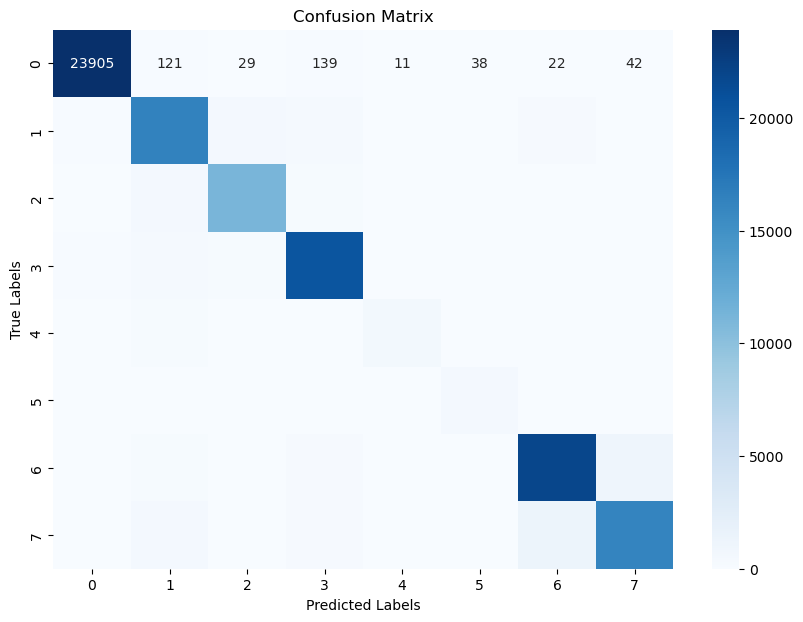

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     24307
           1       0.89      0.92      0.90     17930
           2       0.92      0.93      0.92     12060
           3       0.93      0.96      0.95     21424
           4       0.93      0.65      0.76       941
           5       0.83      0.85      0.84       656
           6       0.93      0.93      0.93     23688
           7       0.92      0.88      0.90     18425

    accuracy                           0.93    119431
   macro avg       0.92      0.89      0.90    119431
weighted avg       0.93      0.93      0.93    119431



In [12]:
evaluate_model_with_cm(model, train_loader, num_classes=8)

validation data

Evaluation Progress: 100%|██████████| 1169/1169 [00:21<00:00, 55.10it/s]


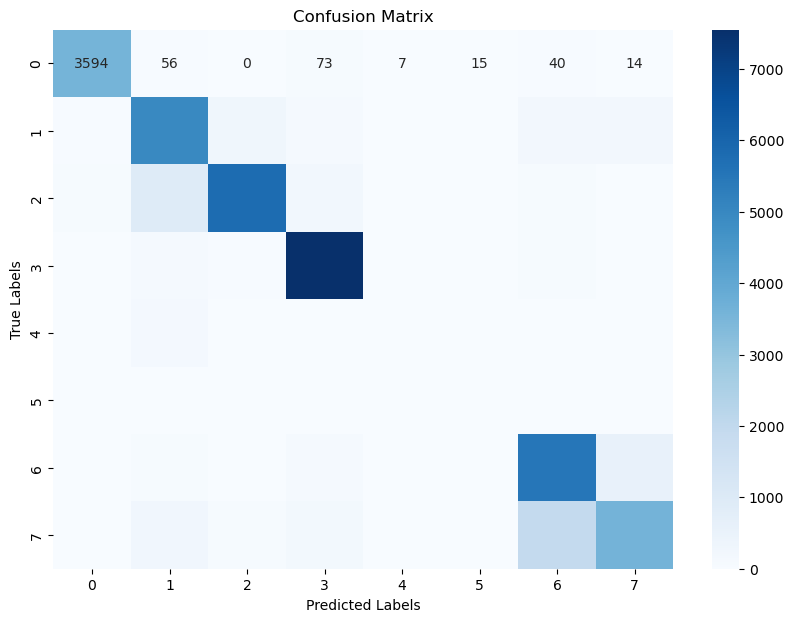

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      3799
           1       0.75      0.84      0.79      5914
           2       0.93      0.81      0.86      7178
           3       0.90      0.96      0.93      7845
           4       0.41      0.06      0.11       195
           5       0.00      0.00      0.00         0
           6       0.70      0.87      0.78      6312
           7       0.81      0.59      0.68      6148

    accuracy                           0.83     37391
   macro avg       0.68      0.63      0.64     37391
weighted avg       0.84      0.83      0.83     37391



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
evaluate_model_with_cm(model, val_loader, num_classes=8)

## NDVI 추가

In [13]:
large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\with_ndvi" #원천데이터 주소
bands = 5 #밴드 수

transform = get_transform(bands)

train_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = lambda box_number: not test_filter(box_number),
    transform=transform
)

val_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = test_filter,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [14]:
model = TreeSpeciesClassifier(bands=bands , num_classes=8).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 모델 학습

In [15]:
train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, patience=100)
torch.save(model, "./video_withd_ndvi_30.pth")

100%|██████████| 3733/3733 [06:07<00:00, 10.16it/s]


Epoch [1/30], Train Loss: 0.6738, Train Accuracy: 75.53%, Val Loss: 0.6266, Val Accuracy: 79.31%


100%|██████████| 3733/3733 [06:05<00:00, 10.23it/s]


Epoch [2/30], Train Loss: 0.4860, Train Accuracy: 82.42%, Val Loss: 0.6997, Val Accuracy: 76.47%


100%|██████████| 3733/3733 [06:12<00:00, 10.02it/s]


...

Epoch [28/30], Train Loss: 0.2317, Train Accuracy: 91.60%, Val Loss: 0.6164, Val Accuracy: 83.84%


100%|██████████| 3733/3733 [06:09<00:00, 10.09it/s]


Epoch [29/30], Train Loss: 0.2256, Train Accuracy: 91.86%, Val Loss: 0.6162, Val Accuracy: 81.18%


100%|██████████| 3733/3733 [06:09<00:00, 10.10it/s]


Epoch [30/30], Train Loss: 0.2172, Train Accuracy: 92.16%, Val Loss: 0.7504, Val Accuracy: 81.48%


### 모델 테스트

train data

Evaluation Progress: 100%|██████████| 3733/3733 [01:15<00:00, 49.26it/s]


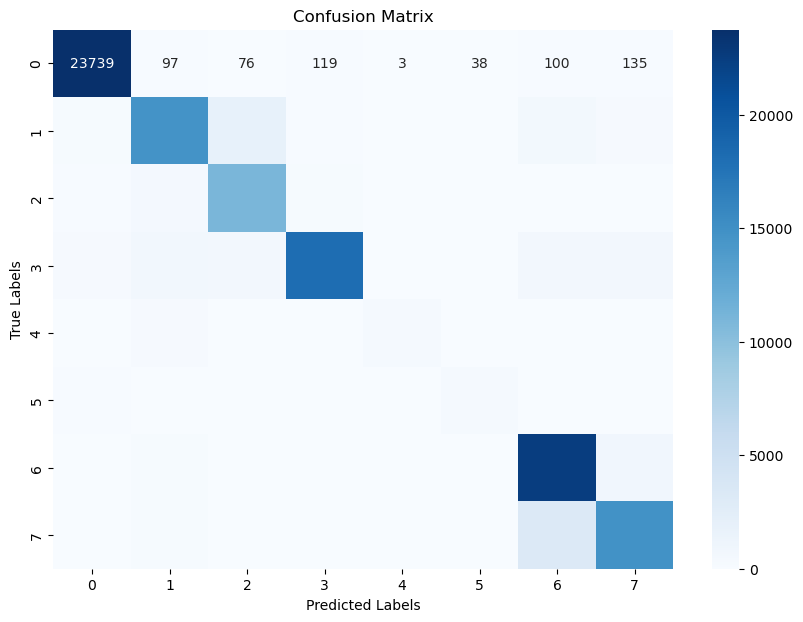

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     24307
           1       0.87      0.82      0.84     17930
           2       0.79      0.91      0.85     12060
           3       0.97      0.85      0.90     21424
           4       0.70      0.48      0.57       941
           5       0.73      0.65      0.69       656
           6       0.83      0.95      0.88     23688
           7       0.88      0.80      0.84     18425

    accuracy                           0.88    119431
   macro avg       0.84      0.81      0.82    119431
weighted avg       0.89      0.88      0.88    119431



In [16]:
evaluate_model_with_cm(model, train_loader, num_classes=8)

validation data

Evaluation Progress: 100%|██████████| 1169/1169 [00:23<00:00, 49.62it/s]


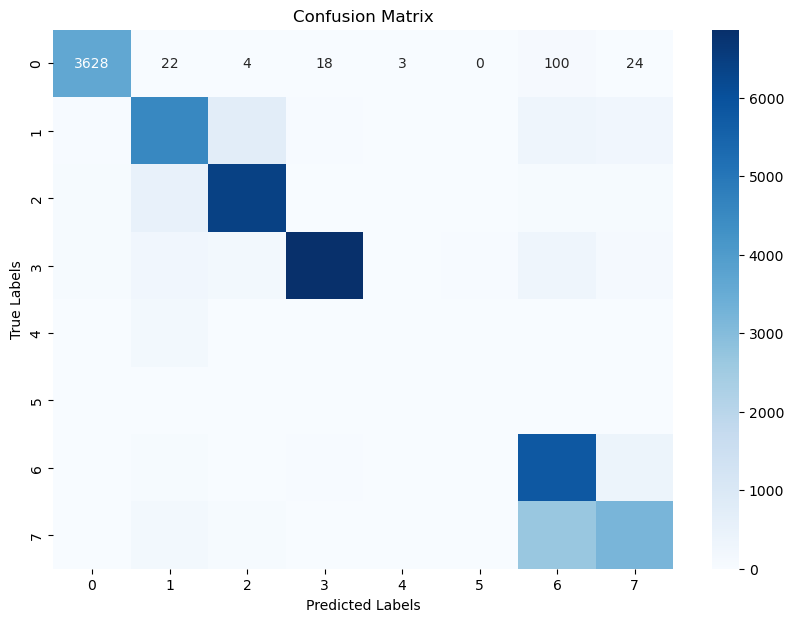

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      3799
           1       0.79      0.77      0.78      5914
           2       0.86      0.89      0.88      7178
           3       0.98      0.88      0.93      7845
           4       0.16      0.05      0.07       195
           5       0.00      0.00      0.00         0
           6       0.63      0.92      0.75      6312
           7       0.79      0.52      0.63      6148

    accuracy                           0.81     37391
   macro avg       0.65      0.62      0.62     37391
weighted avg       0.83      0.81      0.81     37391



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
evaluate_model_with_cm(model, val_loader, num_classes=8)

## NDVI, Sentinel_2(B05, B06, B07, B11, B12) 데이터 추가

In [18]:
large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\with_ndvi_s2" #원천데이터 주소
bands = 10 #밴드 수

transform = get_transform(bands)

train_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = lambda box_number: not test_filter(box_number),
    transform=transform
)

val_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = test_filter,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [19]:
model = TreeSpeciesClassifier(bands=bands , num_classes=8).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 모델 학습

In [20]:
train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, patience=100)
torch.save(model, "./video_withd_ndvi_s2_30.pth")

100%|██████████| 3733/3733 [09:03<00:00,  6.87it/s]


Epoch [1/30], Train Loss: 0.7016, Train Accuracy: 74.10%, Val Loss: 0.5874, Val Accuracy: 79.90%


100%|██████████| 3733/3733 [09:15<00:00,  6.72it/s]


Epoch [2/30], Train Loss: 0.4938, Train Accuracy: 82.20%, Val Loss: 0.6829, Val Accuracy: 75.49%


100%|██████████| 3733/3733 [08:53<00:00,  6.99it/s]


...

Epoch [28/30], Train Loss: 0.2536, Train Accuracy: 90.91%, Val Loss: 0.5244, Val Accuracy: 84.15%


100%|██████████| 3733/3733 [08:53<00:00,  7.00it/s]


Epoch [29/30], Train Loss: 0.3126, Train Accuracy: 90.02%, Val Loss: 0.6025, Val Accuracy: 82.75%


100%|██████████| 3733/3733 [08:52<00:00,  7.01it/s]


Epoch [30/30], Train Loss: 0.2457, Train Accuracy: 91.25%, Val Loss: 0.5703, Val Accuracy: 83.28%


### 모델 테스트

train data

Evaluation Progress: 100%|██████████| 3733/3733 [01:57<00:00, 31.64it/s]


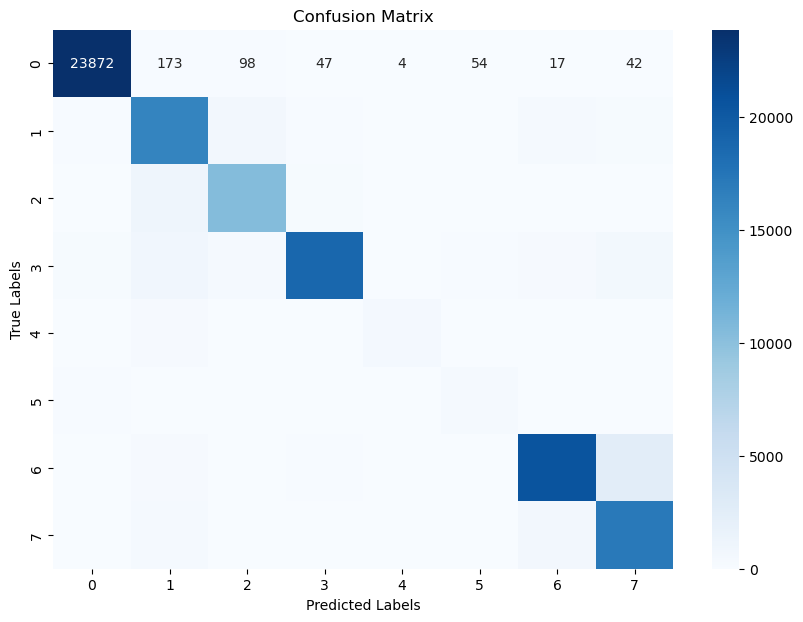

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     24307
           1       0.83      0.90      0.87     17930
           2       0.89      0.87      0.88     12060
           3       0.97      0.88      0.92     21424
           4       0.69      0.52      0.59       941
           5       0.69      0.69      0.69       656
           6       0.93      0.87      0.90     23688
           7       0.83      0.93      0.88     18425

    accuracy                           0.90    119431
   macro avg       0.85      0.83      0.84    119431
weighted avg       0.91      0.90      0.90    119431



In [21]:
evaluate_model_with_cm(model, train_loader, num_classes=8)

val data

Evaluation Progress: 100%|██████████| 1169/1169 [00:36<00:00, 31.75it/s]


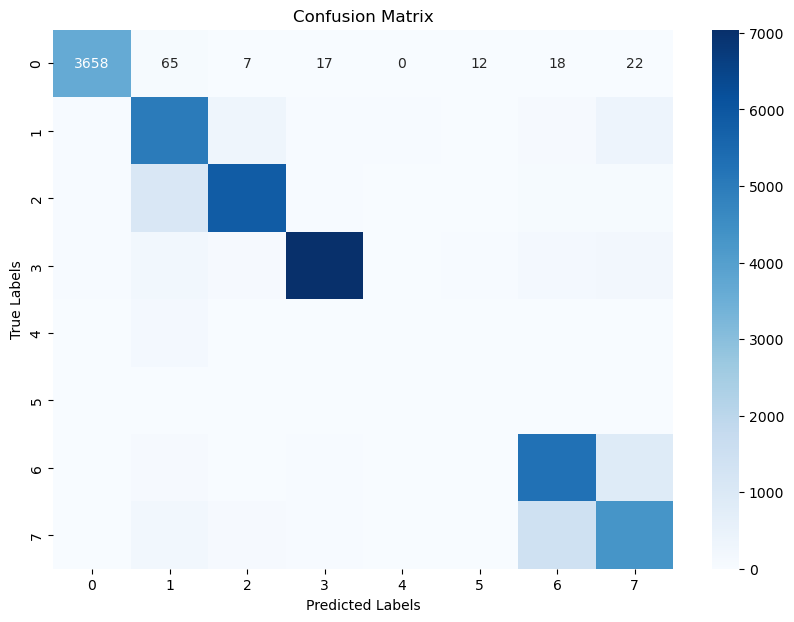

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      3799
           1       0.73      0.85      0.78      5914
           2       0.91      0.81      0.86      7178
           3       0.97      0.90      0.93      7845
           4       0.32      0.13      0.18       195
           5       0.00      0.00      0.00         0
           6       0.75      0.83      0.79      6312
           7       0.74      0.70      0.72      6148

    accuracy                           0.83     37391
   macro avg       0.67      0.65      0.65     37391
weighted avg       0.84      0.83      0.83     37391



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
evaluate_model_with_cm(model, val_loader, num_classes=8)

## 왜 NDVI가 도움이 안될까? NDVI만을 이용해보자

In [45]:
large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\ndvi_only" #원천데이터 주소
bands = 1 #밴드 수

transform = get_transform(bands)

train_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = lambda box_number: not test_filter(box_number),
    transform=transform
)

val_dataset = TiffDataset(
    large_tif_dir = large_tif_dir,
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = test_filter,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [47]:
model = TreeSpeciesClassifier(bands=bands , num_classes=8).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 모델 학습

In [48]:
train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, patience=100)
torch.save(model, "./video_ndvi only_30.pth")

100%|██████████| 3733/3733 [04:52<00:00, 12.75it/s]


Epoch [1/30], Train Loss: 1.2734, Train Accuracy: 63.92%, Val Loss: 2.9312, Val Accuracy: 22.23%


100%|██████████| 3733/3733 [05:57<00:00, 10.45it/s]


Epoch [2/30], Train Loss: 1.1576, Train Accuracy: 53.29%, Val Loss: 1.6240, Val Accuracy: 31.99%


100%|██████████| 3733/3733 [05:51<00:00, 10.63it/s]


...

Epoch [28/30], Train Loss: 0.7013, Train Accuracy: 72.52%, Val Loss: 2.1292, Val Accuracy: 48.62%


100%|██████████| 3733/3733 [03:25<00:00, 18.20it/s]


Epoch [29/30], Train Loss: 0.6932, Train Accuracy: 72.76%, Val Loss: 12.4566, Val Accuracy: 23.03%


100%|██████████| 3733/3733 [03:22<00:00, 18.43it/s]


Epoch [30/30], Train Loss: 0.7036, Train Accuracy: 72.64%, Val Loss: 2.5527, Val Accuracy: 38.30%


### 모델 테스트

train data

Evaluation Progress: 100%|██████████| 3733/3733 [00:40<00:00, 92.54it/s]


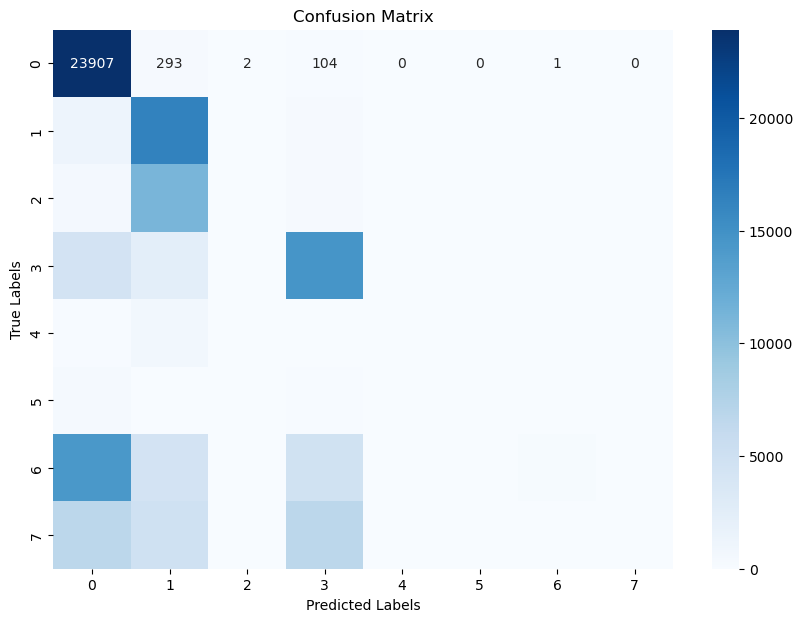

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.98      0.63     24307
           1       0.40      0.91      0.56     17930
           2       0.51      0.00      0.01     12060
           3       0.54      0.68      0.61     21424
           4       0.00      0.00      0.00       941
           5       0.00      0.00      0.00       656
           6       0.99      0.01      0.02     23688
           7       0.00      0.00      0.00     18425

    accuracy                           0.46    119431
   macro avg       0.36      0.32      0.23    119431
weighted avg       0.50      0.46      0.32    119431



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [49]:
evaluate_model_with_cm(model, train_loader, num_classes=8)

validation data

Evaluation Progress: 100%|██████████| 1169/1169 [00:12<00:00, 92.23it/s]


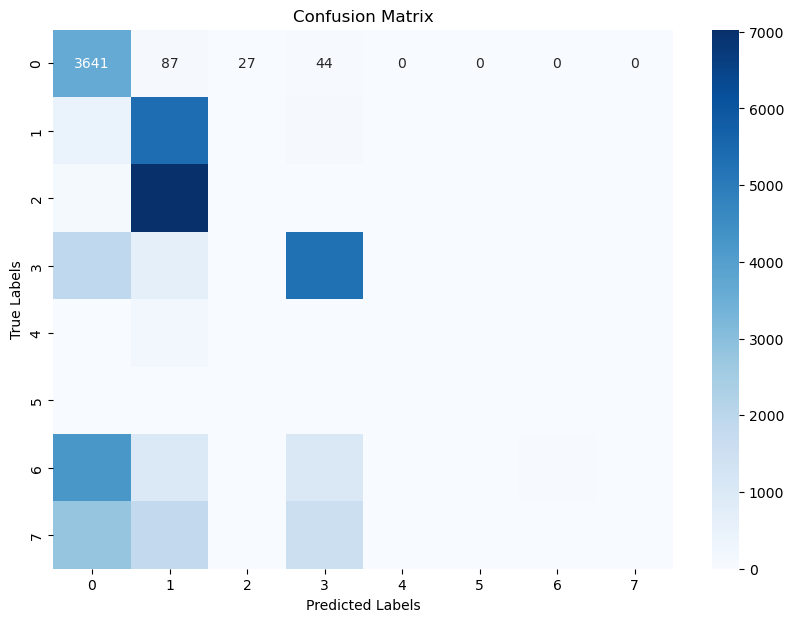

Classification Report:
              precision    recall  f1-score   support

           0       0.28      0.96      0.43      3799
           1       0.33      0.91      0.49      5914
           2       0.05      0.00      0.00      7178
           3       0.66      0.67      0.67      7845
           4       0.00      0.00      0.00       195
           5       0.00      0.00      0.00         0
           6       1.00      0.01      0.01      6312
           7       0.00      0.00      0.00      6148

    accuracy                           0.38     37391
   macro avg       0.29      0.32      0.20     37391
weighted avg       0.40      0.38      0.26     37391



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-pac

In [50]:
evaluate_model_with_cm(model, val_loader, num_classes=8)